In [1]:
# Install libraries if needed
!pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving sleep_mobile_stress_dataset_15000.csv to sleep_mobile_stress_dataset_15000 (1).csv


In [4]:
# Save processed dataset
df.to_csv("processed_sleep_mobile_stress_dataset.csv", index=False)

print("Dataset stored as CSV successfully.")

Dataset stored as CSV successfully.


In [5]:
import sqlite3

conn = sqlite3.connect("sleep_stress_database.db")

df.to_sql("sleep_stress_data", conn, if_exists="replace", index=False)

print("Dataset stored in SQLite database.")

Dataset stored in SQLite database.


In [6]:
query = "SELECT * FROM sleep_stress_data LIMIT 10"

pd.read_sql(query, conn)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99
5,6,56,Male,Teacher,7.26,10,7.79,6.16,10.00,2,50,198,7.85
6,7,36,Female,Teacher,4.56,83,6.81,6.81,5.38,0,19,39,5.52
7,8,40,Male,Manager,3.36,89,6.50,8.75,3.48,2,66,127,4.50
8,9,28,Male,Student,2.30,109,7.57,8.05,3.46,3,103,99,2.52
9,10,28,Female,Manager,9.75,46,4.73,5.52,10.00,3,56,121,10.00


In [7]:
df["digital_behavior_index"] = (
    df["daily_screen_time_hours"] +
    df["phone_usage_before_sleep_minutes"] / 60 +
    df["notifications_received_per_day"] / 100
)

df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,digital_behavior_index
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57,5.883333
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91,5.373333
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05,5.033333
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92,11.800000
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99,6.123333


In [8]:
df["lifestyle_score"] = (
    df["sleep_duration_hours"] +
    df["physical_activity_minutes"] / 60 -
    df["caffeine_intake_cups"] * 0.2
)

df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,digital_behavior_index,lifestyle_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57,5.883333,5.893333
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91,5.373333,7.626667
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05,5.033333,4.783333
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92,11.800000,6.730000
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99,6.123333,8.303333


In [9]:
df["stress_risk_score"] = (
    df["stress_level"] +
    df["mental_fatigue_score"] +
    df["digital_behavior_index"]
) / 3

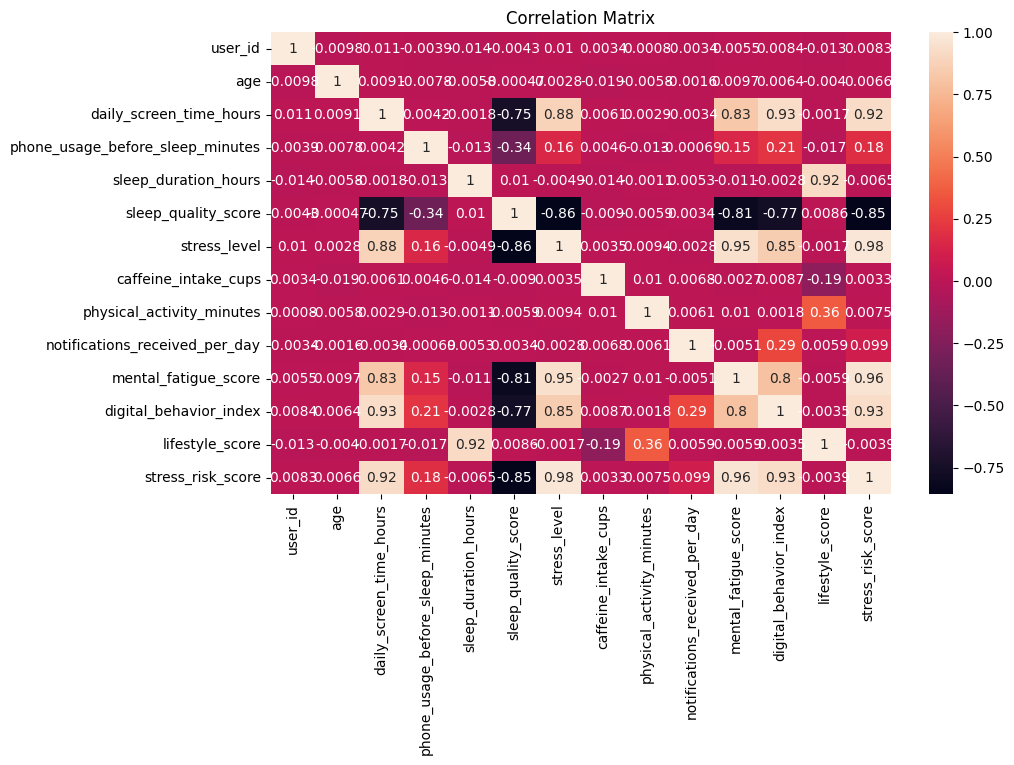

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Matrix")
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

features = [
    "daily_screen_time_hours",
    "sleep_duration_hours",
    "stress_level",
    "mental_fatigue_score",
    "physical_activity_minutes"
]

X = df[features]

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

df["user_cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,digital_behavior_index,lifestyle_score,stress_risk_score,user_cluster
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57,5.883333,5.893333,4.314444,1
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91,5.373333,7.626667,3.431111,1
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05,5.033333,4.783333,5.371111,1
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92,11.800000,6.730000,10.573333,3
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99,6.123333,8.303333,6.274444,1


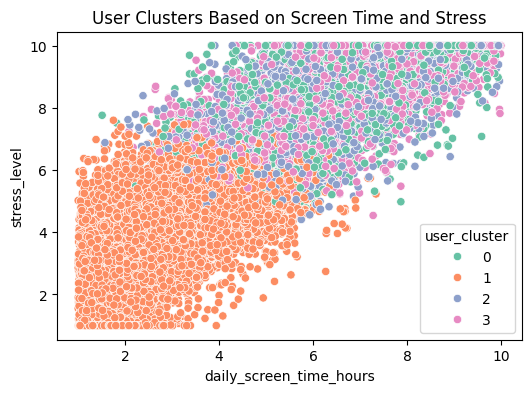

In [16]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=df["daily_screen_time_hours"],
    y=df["stress_level"],
    hue=df["user_cluster"],
    palette="Set2"
)

plt.title("User Clusters Based on Screen Time and Stress")
plt.show()

In [17]:
df.groupby("user_cluster").mean(numeric_only=True)


,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,digital_behavior_index,lifestyle_score,stress_risk_score
user_cluster,,,,,,,,,,,,,,
0,7515.650739,38.652458,7.148872,61.795462,7.912303,5.286844,8.858364,2.004813,80.628051,161.050189,8.702472,9.789299,8.855142,9.116711
1,7428.637583,38.356148,2.878124,55.982236,6.528161,7.772941,3.986700,1.998084,58.022640,160.922153,3.940502,5.420383,7.095588,4.449195
2,7540.360734,38.386209,7.030948,62.213655,5.155024,5.356467,8.747819,1.990489,82.971128,162.328465,8.621036,9.691127,6.139778,9.019994
3,7574.276946,38.659912,7.195756,62.045228,6.451474,5.261184,8.895598,2.002056,22.137151,159.457269,8.743891,9.824416,6.420016,9.154635
